# Basis Testing

Notebook for playing with and testing construction of Basis and matrices for GCR

Want a form of $\bold{d}=(d_{0}(\nu_0), d_{0}(\nu_1) ... d_{0}(\nu_{\rm f}), d_{1}(\nu_0), d_{1}(\nu_1) ... d_{{\rm c}}(\nu_{\rm f}))$
where there are $n$ calibrators and $f$ frequency channels

H matrix is a (c x f x 3) matrix

Each $H = (h_{unc}, h_{cos}, h_{sin})$


Matrix will be a (n_params, n_freqs x n_calibrators x n_observations (in time))



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gcr.noise_wave_gcr as noise_wave_gcr
import simulation.receiver_simulation as receiver_simulation
import gcr.transfer_matrix_construction as transfer_matrix_construction

from scipy.sparse.linalg import cg
from scipy.linalg import solve

import astropy.units as un

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

# Test Observation

Describe the noise-wave terms with a nth degree polynomial or Chebyshev Polynomials. Also use this to desribe the gain and the noise-offset.

Use $n$ calibrators and see how things change

Test the number of Polynomials

Think about how the signal covariance is defined. Jeffreys Priors? 10% of nominal values?



In [2]:
def chebyshev_model(x, ncoeffs, amp):
    """
    This convenience function produces a Chebyshev series model in 
    frequency/time/etc. to produce a model for various components 
    and systematic effects.
    
    Parameters:
        x (array_like):
            Time/freq. variable.
        ncoeffs (int):
            No. of Chebyshev coefficients to use.
        amp (float):
            Overall amplitude of the Chebyshev polynomial.
    
    Returns:
        fn (array_like):
            Chebyshev function. 
    """
    # Chebyshev parameters
    coeffs = amp * np.random.randn(ncoeffs)

    # Construct time- and frequency-dependent random Chebyshev functions
    xx = np.linspace(-1., 1., x.size)
    fn = np.polynomial.chebyshev.Chebyshev(coeffs)(xx)
    
    # Return values
    return fn

def gaussian(x, mu, sig):
    return (1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

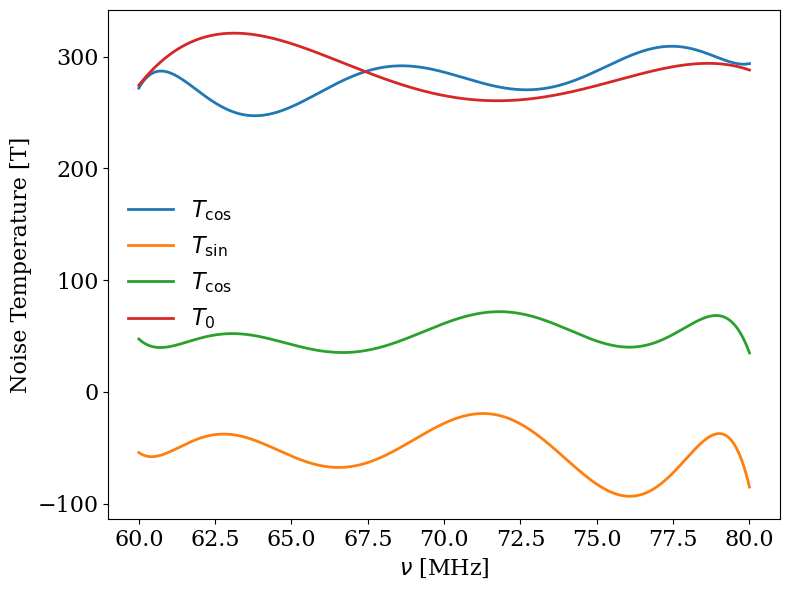

In [3]:
Tload1 = 293. # K
Tload2 = Tload1 + 40 # K

nu_centre = 70e6 # Hz
nu_bandpass = 20e6 # Hz
n_freqs = int(2**12)

t_int = 60 # s
del_nu = nu_bandpass / n_freqs

temp_sens_variance = 0.01**2

freqs = np.linspace(nu_centre - (nu_bandpass/2),
                    nu_centre+(nu_bandpass/2),
                    num=n_freqs)

T_unc = 300 + chebyshev_model(freqs,
                        ncoeffs=8,
                        amp=20)


T_sin = -50 +chebyshev_model(freqs,
                        ncoeffs=8,
                        amp=10)

T_cos = 50+ chebyshev_model(freqs,
                        ncoeffs=8,
                        amp=5)

T_0 = 300 + chebyshev_model(freqs, ncoeffs=5,
                            amp=12)

bandpass = 10000 + chebyshev_model(freqs, ncoeffs=20, amp=100)


gamma_rec_real = gaussian(freqs, 70e6, 20e6) * 1e6
gamma_rec_imag = gaussian(freqs, 60e6, 20e6) * 1e6
gamma_rec = gamma_rec_real + 1j*gamma_rec_imag


## Fitting Orders
unc_polyorder = 10
cos_polyorder = 10
sin_polyorder = 10

reference_frequency = 70e6

plt.plot(freqs / 1e6, T_unc, label=r'$T_{\rm cos}$', lw=2)
plt.plot(freqs / 1e6, T_sin, label=r'$T_{\rm sin}$', lw=2)
plt.plot(freqs / 1e6, T_cos, label=r'$T_{\rm cos}$', lw=2)
plt.plot(freqs / 1e6, T_0, label=r'$T_{ 0}$', lw=2)
plt.ylabel('Noise Temperature [T]', fontsize=16)
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)

plt.tick_params(axis='both', labelsize=16)
plt.legend(fontsize=16, frameon=False)
plt.gcf().set_size_inches((8., 6.))
plt.tight_layout()
plt.show()




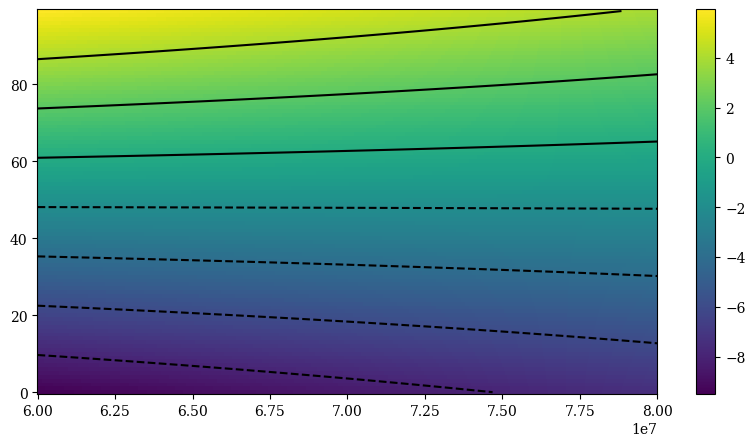

In [4]:
### Test of creating a 2d chebyshev surface...

def chebyshev_model(x, ncoeffs, amp):
    """
    This convenience function produces a Chebyshev series model in 
    frequency/time/etc. to produce a model for various components 
    and systematic effects.
    
    Parameters:
        x (array_like):
            Time/freq. variable.
        ncoeffs (int):
            No. of Chebyshev coefficients to use.
        amp (float):
            Overall amplitude of the Chebyshev polynomial.
    
    Returns:
        fn (array_like):
            Chebyshev function. 
    """
    # Chebyshev parameters
    coeffs = amp * np.random.randn(ncoeffs)

    # Construct time- and frequency-dependent random Chebyshev functions
    xx = np.linspace(-1., 1., x.size)
    fn = np.polynomial.chebyshev.Chebyshev(coeffs)(xx)
    
    # Return values
    return fn


def chebyshev_model_2d(
        freqs:np.ndarray,
        times:np.ndarray,
        n_freq_coeffs:int,
        n_time_coeffs:int,
        amp = float) -> np.ndarray:

    coeffs = np.sqrt(amp) * np.random.randn(n_freq_coeffs,
                                            n_time_coeffs)
    
    xx = np.linspace(-1., 1., freqs.size)
    yy = np.linspace(-1, 1., times.size)

    x_grid, y_grid = np.meshgrid(xx, yy)

    return np.polynomial.chebyshev.chebval2d(x_grid,
                                             y_grid,
                                             coeffs)

times = np.arange(100) # 100 seconds

varying_field = chebyshev_model_2d(freqs, times,
                            n_freq_coeffs=2,
                            n_time_coeffs=2,
                            amp=10)

plt.contour(freqs, times, varying_field, colors='black')
plt.pcolormesh(freqs, times, varying_field)

plt.colorbar()
plt.show()



/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/beams_env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


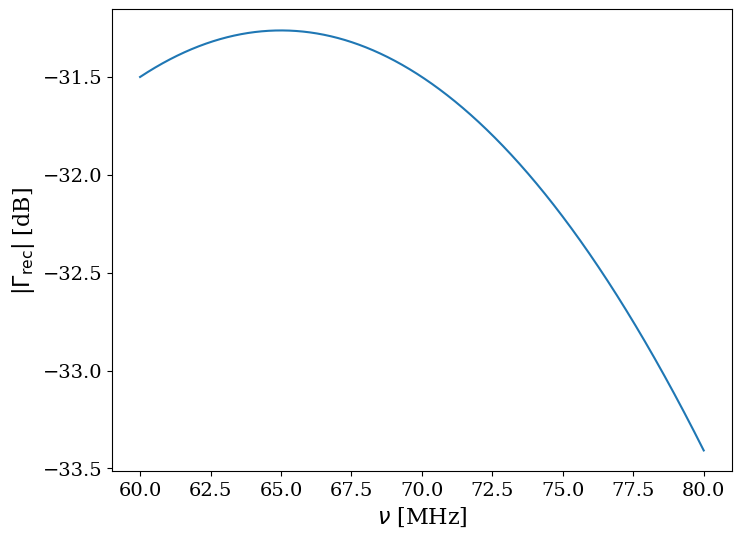

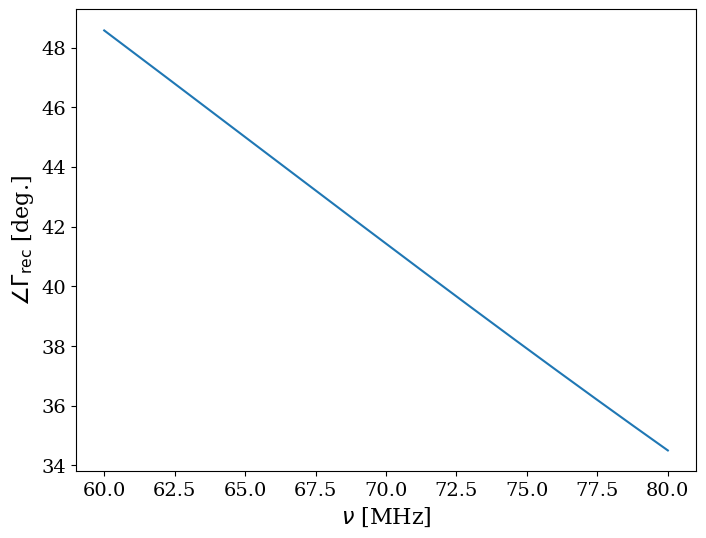

In [5]:
# Gamma Req


gamma_rec_real = gaussian(freqs, 70e6, 20e6) * 1e6
gamma_rec_imag = gaussian(freqs, 60e6, 20e6) * 1e6
gamma_rec = gamma_rec_real + 1j*gamma_rec_imag
plt.plot(freqs / 1e6, 20*np.log10(gamma_rec))
plt.ylabel(r'$|\Gamma_{\rm rec}|$ [dB]', fontsize=16)
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)
plt.tick_params('both', labelsize=14)
plt.gcf().set_size_inches((8., 6.))
plt.show()

plt.plot(freqs / 1e6, np.rad2deg(np.angle(gamma_rec)))
plt.ylabel(r'$\angle \Gamma_{\rm rec}$ [deg.]', fontsize=16)
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)
plt.tick_params('both', labelsize=14)
plt.gcf().set_size_inches((8., 6.))
plt.show()

/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_54043/1365879425.py:39: RuntimeWarning: invalid value encountered in log10
  ax1.plot(freqs / 1e6, 20*np.log10(gamma_src), label=label)


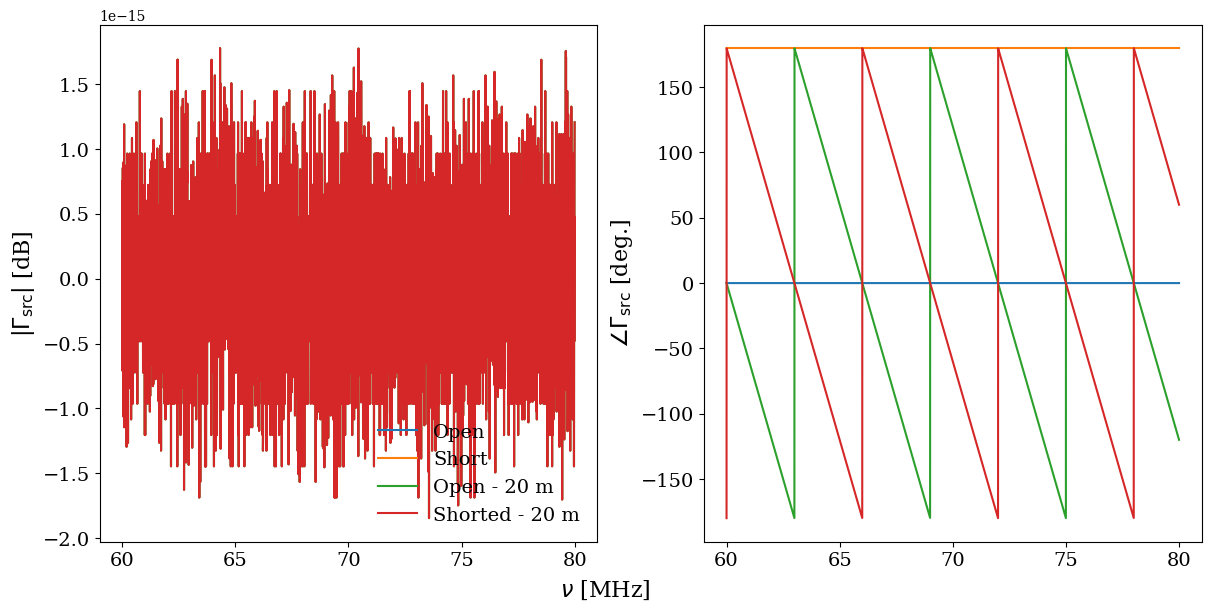

In [6]:
open_cable_gamma = receiver_simulation.get_gammas(termination_type='open',
                                                  freq_array=freqs)
short_cable_gamma = receiver_simulation.get_gammas(termination_type='short',
                                                   freq_array=freqs)
long_open_gamma = receiver_simulation.get_gammas(termination_type='open',
                                                 freq_array=freqs,
                                                 cable_params=receiver_simulation.calculate_cable_params(length=20,
                                                                                                         loss=1, freq_array=freqs, velocity_factor=0.8))
long_short_gamma = receiver_simulation.get_gammas(termination_type='short',
                                                 freq_array=freqs,
                                                 cable_params=receiver_simulation.calculate_cable_params(length=20,
                                                                                                         loss=1, freq_array=freqs, velocity_factor=0.8))

medium_open = receiver_simulation.get_gammas(termination_type='open',
                                                 freq_array=freqs,
                                                 cable_params=receiver_simulation.calculate_cable_params(length=5,
                                                                                                         loss=1, freq_array=freqs, velocity_factor=0.8))

medium_short = receiver_simulation.get_gammas(termination_type='short',
                                                 freq_array=freqs,
                                                 cable_params=receiver_simulation.calculate_cable_params(length=5,
                                                                                                         loss=1, freq_array=freqs, velocity_factor=0.8))


mismatch_termination = receiver_simulation.get_gammas(termination_type='',
                                                      termination_impedence=75,
                                                      freq_array=freqs)

mismatch_termination_2 = receiver_simulation.get_gammas(termination_type='',
                                                      termination_impedence=25,
                                                      freq_array=freqs)
gamma_src_list = [open_cable_gamma, short_cable_gamma, long_open_gamma, long_short_gamma]#, mismatch_termination, mismatch_termination_2, medium_open, medium_short]

gamma_src_list_labels = ['Open', 'Short', 'Open - 20 m', 'Shorted - 20 m']#, r'$75 \Omega$', r'$25 \Omega$', 'Open - 5 m', 'Shorted - 5 m',]


fig, (ax1, ax2) = plt.subplots(ncols=2, layout='constrained')
for gamma_src, label in zip(gamma_src_list, gamma_src_list_labels):
    ax1.plot(freqs / 1e6, 20*np.log10(gamma_src), label=label)
    ax2.plot(freqs / 1e6, np.rad2deg(np.angle(gamma_src)), label=label)
ax1.tick_params('both', labelsize=14)
ax2.tick_params('both', labelsize=14)
ax1.set_ylabel(r'$|\Gamma_{\rm src}|$ [dB]', fontsize=16)
ax2.set_ylabel(r'$ \angle \Gamma_{\rm src} $ [deg.]', fontsize=16)
fig.supxlabel(r'$\nu$ [MHz]', fontsize=16)
ax1.legend(fontsize=14, frameon=False)
plt.gcf().set_size_inches((12., 6.))
plt.show()


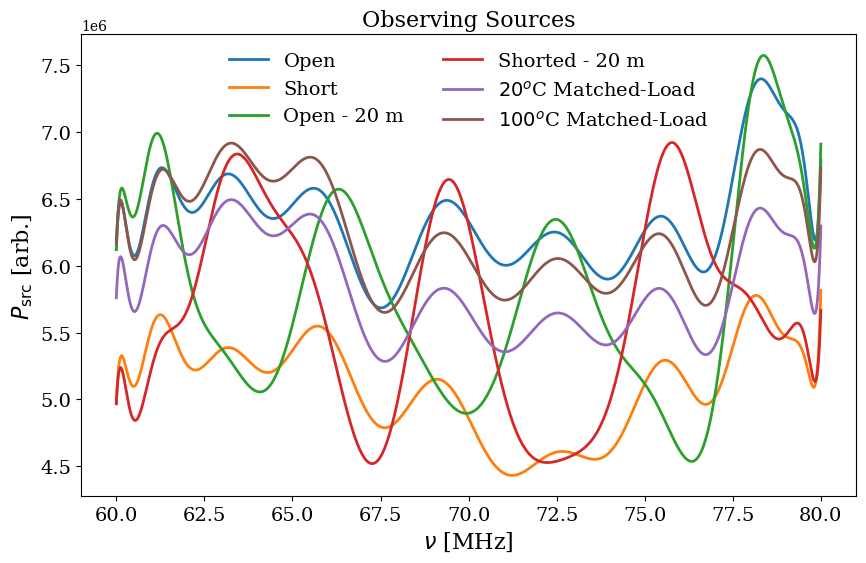

In [7]:
for gamma_src, label in zip(gamma_src_list, gamma_src_list_labels):
    plt.plot(freqs / 1e6, receiver_simulation.compute_radiometer_power(T_src=Tload1,
                                             T_unc=T_unc,
                                             T_sin=T_sin,
                                             T_cos=T_cos,
                                             T_0=T_0,
                                             Gamma_src=gamma_src,
                                             Gamma_rec=gamma_rec, gain=bandpass), label=label, lw=2)
    

plt.plot(freqs / 1e6, receiver_simulation.compute_radiometer_power(T_src=Tload1,
                                             T_unc=T_unc,
                                             T_sin=T_sin,
                                             T_cos=T_cos,
                                             T_0=T_0,
                                             Gamma_src=0,
                                             Gamma_rec=gamma_rec, gain=bandpass), label=r'$20 ^o$C Matched-Load', lw=2)

plt.plot(freqs / 1e6, receiver_simulation.compute_radiometer_power(T_src=Tload2,
                                             T_unc=T_unc,
                                             T_sin=T_sin,
                                             T_cos=T_cos,
                                             T_0=T_0,
                                             Gamma_src=0,
                                             Gamma_rec=gamma_rec, gain=bandpass), label=r'$100 ^o$C Matched-Load', lw=2)
plt.title('Observing Sources', fontsize=16)
plt.ylabel(r'$P_{\rm src}$ [arb.]', fontsize=16)
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)
plt.legend(fontsize=14, frameon=False, ncols=2)
plt.tick_params('both', labelsize=14)
plt.gcf().set_size_inches((10.0, 6.0))
plt.show()

In [8]:
# Simulate Observation Of Calibrators .. No time dependance for now

observation_dict = receiver_simulation.return_measurements_i(T_l=Tload1,
                                                             T_ns=Tload2,
                                                             T_src=Tload1,
                                                             gamma_rec=gamma_rec,
                                                             gamma_src_list=gamma_src_list,
                                                             gamma_ns=10**(-60/10),
                                                             gamma_l=10**(-60/10),
                                                             t_int=t_int,
                                                             delta_nu=del_nu,
                                                             T_sin=T_sin,
                                                             T_unc=T_unc,
                                                             T_cos=T_cos,
                                                             T_0=T_0,
                                                             gain=bandpass,
                                                             temp_sens_variance=temp_sens_variance,
                                                             obs_freqs=freqs)




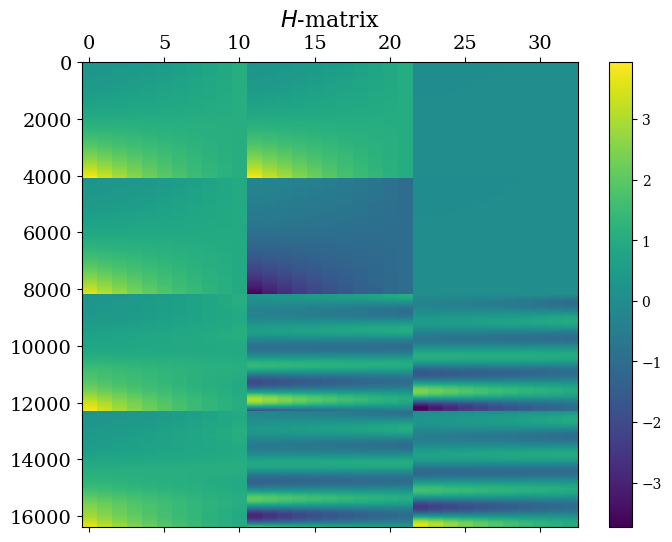

In [9]:

H_matrix = noise_wave_gcr.construct_H_matrix(freqs,
                                             gamma_src_list=gamma_src_list,
                                             gamma_rec=gamma_rec,
                                             unc_polyorder=unc_polyorder,
                                             cos_polyorder=cos_polyorder,
                                             sin_polyorder=sin_polyorder,
                                             reference_frequency=reference_frequency)

plt.matshow(H_matrix, aspect='auto')
plt.tick_params('both', labelsize=14)
plt.colorbar()
plt.title(r'$H$-matrix', fontsize=16)
plt.gcf().set_size_inches((8.0, 6.0))
plt.show()




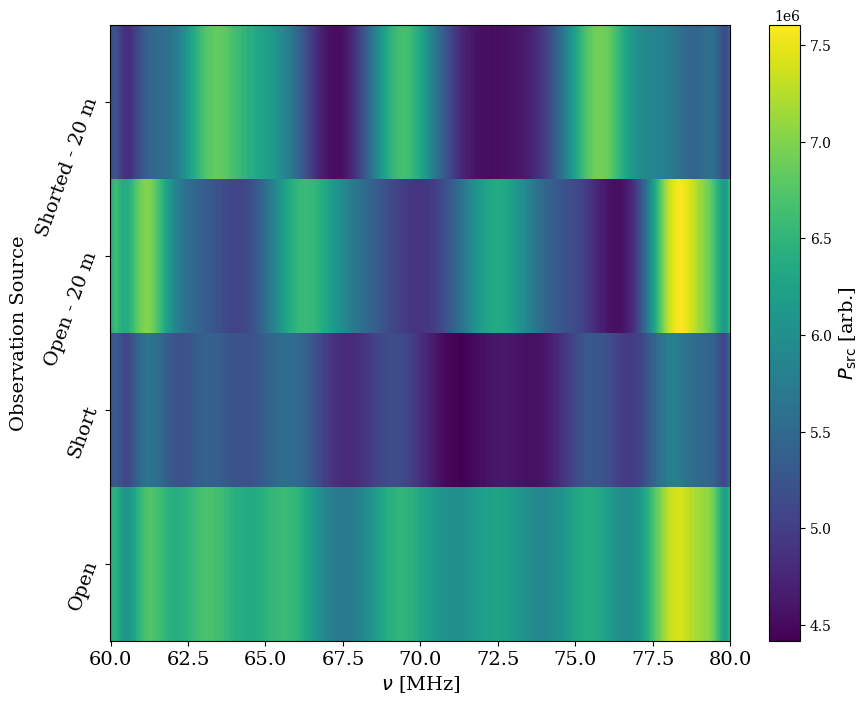

In [10]:
plt.pcolormesh(freqs / 1e6, gamma_src_list_labels, observation_dict['P_src'])
a = plt.colorbar(label=r'$P_{\rm src}$ [arb.]')
plt.ylabel('Observation Source', fontsize=14)
plt.xlabel(r'$\nu$ [MHz]', fontsize=14)
plt.yticks(rotation=70)
plt.tick_params('both', labelsize=14)
a.set_label(label=r'$P_{\rm src}$ [arb.]', fontsize=14)
plt.gcf().set_size_inches((10., 8.))
plt.show()




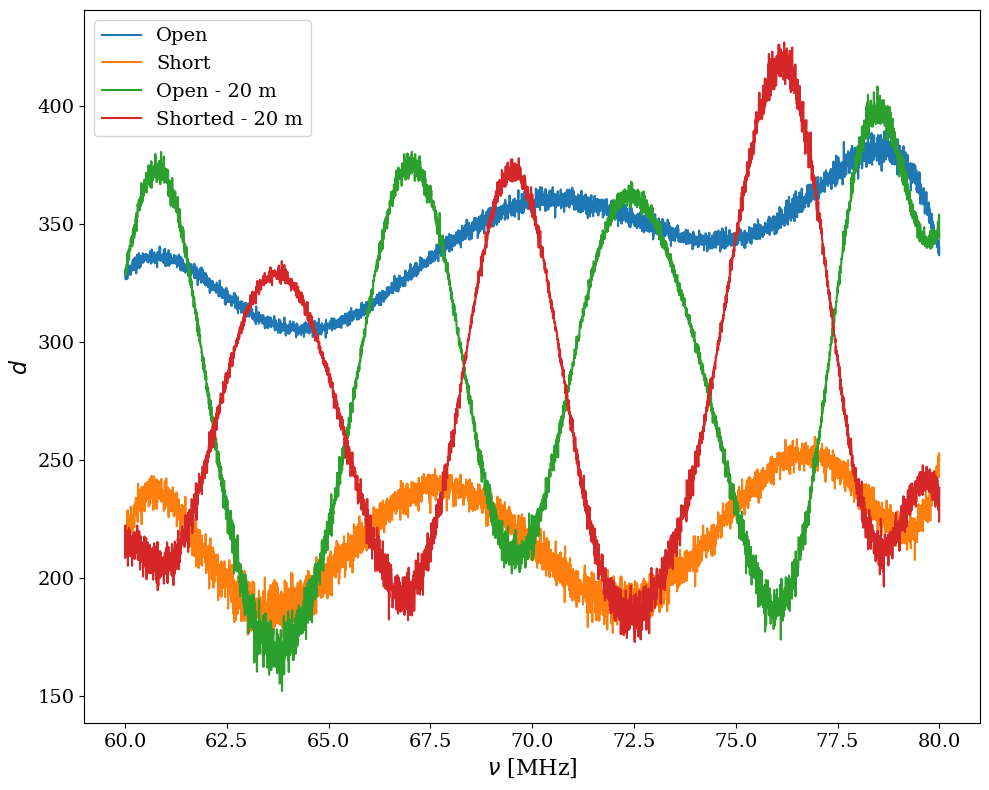

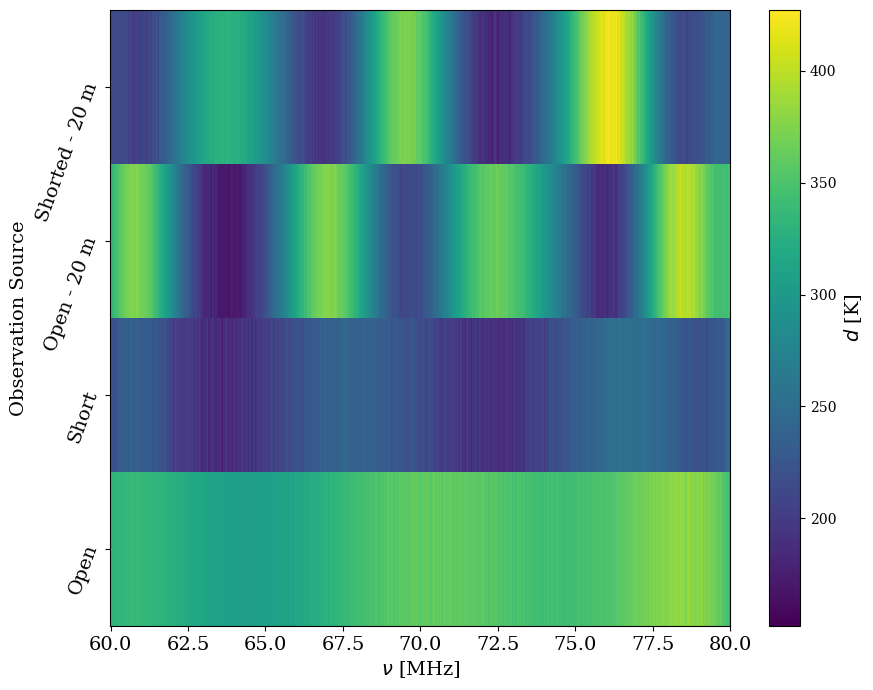

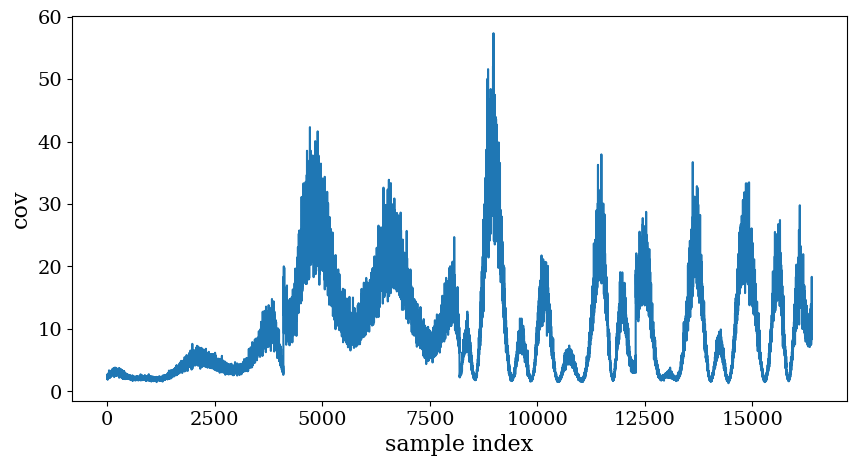

d_flat  (16384,)
N_inv (16384,)


In [11]:
# construct data vector
data_waterfall = np.ones((len(gamma_src_list), n_freqs))
ncov_waterfall = np.ones_like(data_waterfall)


for i in range(len(gamma_src_list)):
    d, ncov = noise_wave_gcr.construct_d_vector_and_cov_matrix(p_src=observation_dict['P_src'][i],
                                                               p_l=observation_dict['P_L'][i],
                                                               p_ns=observation_dict['P_NS'][i],
                                                               T_src=observation_dict['T_src'][i],
                                                               T_ns=observation_dict['T_NS'][i],
                                                               T_l=observation_dict['T_L'][i],
                                                               Gamma_rec=gamma_rec,
                                                               Gamma_src=gamma_src_list[i],
                                                               t_int=t_int,
                                                               delta_nu=del_nu,
                                                               temp_sens_variance=temp_sens_variance)
    data_waterfall[i] = d
    ncov_waterfall[i] = ncov
    plt.plot(freqs / 1e6, d, label=gamma_src_list_labels[i])




plt.ylabel('$d$', fontsize=16)
plt.xlabel(r'$\nu$ [MHz]', fontsize=16)
plt.gcf().set_size_inches((10., 8.))
plt.tick_params('both', labelsize=14)
plt.legend(frameon=True, fontsize=14)
plt.tight_layout()
plt.show()

plt.pcolormesh(freqs / 1e6, gamma_src_list_labels, data_waterfall)
a = plt.colorbar(label=r'$d$ [K]')
plt.ylabel('Observation Source', fontsize=14)
plt.xlabel(r'$\nu$ [MHz]', fontsize=14)
plt.yticks(rotation=70)
plt.tick_params('both', labelsize=14)
a.set_label(label=r'$d$ [K]', fontsize=14)
plt.gcf().set_size_inches((10., 8.))
plt.show()


plt.plot(ncov_waterfall.flatten())
plt.ylabel('cov', fontsize=16)
plt.xlabel('sample index', fontsize=16)
plt.tick_params('both', labelsize=14)
plt.show()

N_inv = 1 / ncov_waterfall.flatten()
d_flat = data_waterfall.flatten()

print('d_flat ', d_flat.shape)
print('N_inv', N_inv.shape)

In [12]:
def return_spectrum_polynomial(fitted_params,
                               unc_polyorder,
                               cos_polyorder,
                               sin_polyorder, reference_freq=0):
    unc_params = fitted_params[:unc_polyorder+1]
    cos_params = fitted_params[unc_polyorder+1:unc_polyorder+sin_polyorder+2]
    sin_params = fitted_params[unc_polyorder+cos_polyorder+2:]

    def unc_func(freqs):
        uncf = np.poly1d(unc_params)
        if reference_freq is None:
            return uncf(freqs)
        else:
            return uncf(freqs / reference_freq)
    def cos_func(freqs):
        cosf = np.poly1d(cos_params)
        if reference_freq is None:
            return cosf(freqs)
        else:
            return cosf(freqs / reference_freq)
    def sin_func(freqs):
        sinf = np.poly1d(sin_params)
        if reference_freq is None:
            return sinf(freqs)
        else:
            return sinf(freqs / reference_freq)
    
    return unc_func, cos_func, sin_func


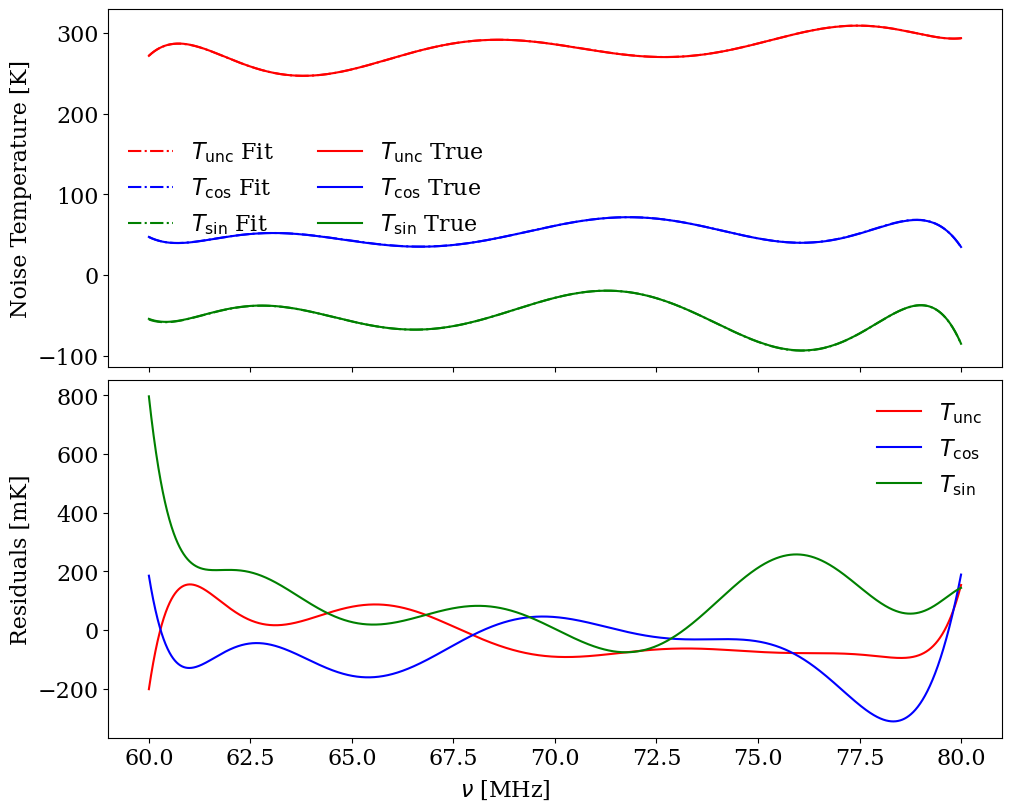

In [13]:
params = np.linalg.lstsq(H_matrix, d_flat)[0]

unc_func, cos_func, sin_func = return_spectrum_polynomial(params,
                                                          unc_polyorder=unc_polyorder,
                                                          cos_polyorder=cos_polyorder,
                                                          sin_polyorder=sin_polyorder,
                                                          reference_freq=reference_frequency)

param_labels = [r'$T_{\rm unc}$', r'$T_{\rm cos}$', r'$T_{\rm sin}$']
original_params = [T_unc, T_cos, T_sin]

old_fit_t_unc = unc_func(freqs)

fig, (ax1, ax2) = plt.subplots(nrows=2,
                               sharex=True,
                               layout='constrained')

ax1.plot(freqs / 1e6, unc_func(freqs),'r-.', label=r'$T_{\rm unc}$ Fit')
ax1.plot(freqs / 1e6, cos_func(freqs),'b-.', label=r'$T_{\rm cos}$ Fit')
ax1.plot(freqs / 1e6, sin_func(freqs),'g-.', label=r'$T_{\rm sin}$ Fit')
ax1.plot(freqs / 1e6, T_unc, 'r-', label=r'$T_{\rm unc}$ True')
ax1.plot(freqs / 1e6, T_cos,'b-', label=r'$T_{\rm cos}$ True')
ax1.plot(freqs / 1e6, T_sin,'g-', label=r'$T_{\rm sin}$ True')

ax1.set_ylabel('Noise Temperature [K]', fontsize=16)
ax1.legend(fontsize=16, frameon=False, ncols=2)
ax1.tick_params('both', labelsize=16)

ax2.plot(freqs / 1e6, 1000*T_unc - 1000*unc_func(freqs) , 'r-', label=r'$T_{\rm unc}$')
ax2.plot(freqs / 1e6, 1000*T_cos - 1000*cos_func(freqs),'b-', label=r'$T_{\rm cos}$')
ax2.plot(freqs / 1e6, 1000*T_sin - 1000*sin_func(freqs),'g-', label=r'$T_{\rm sin}$')
ax2.set_ylabel('Residuals [mK]', fontsize=16)
ax2.tick_params('both', labelsize=16)
ax2.legend(frameon=False, fontsize=16)
fig.supxlabel(r'$\nu$ [MHz]', fontsize=16)
plt.gcf().set_size_inches((10., 8.))
plt.show()


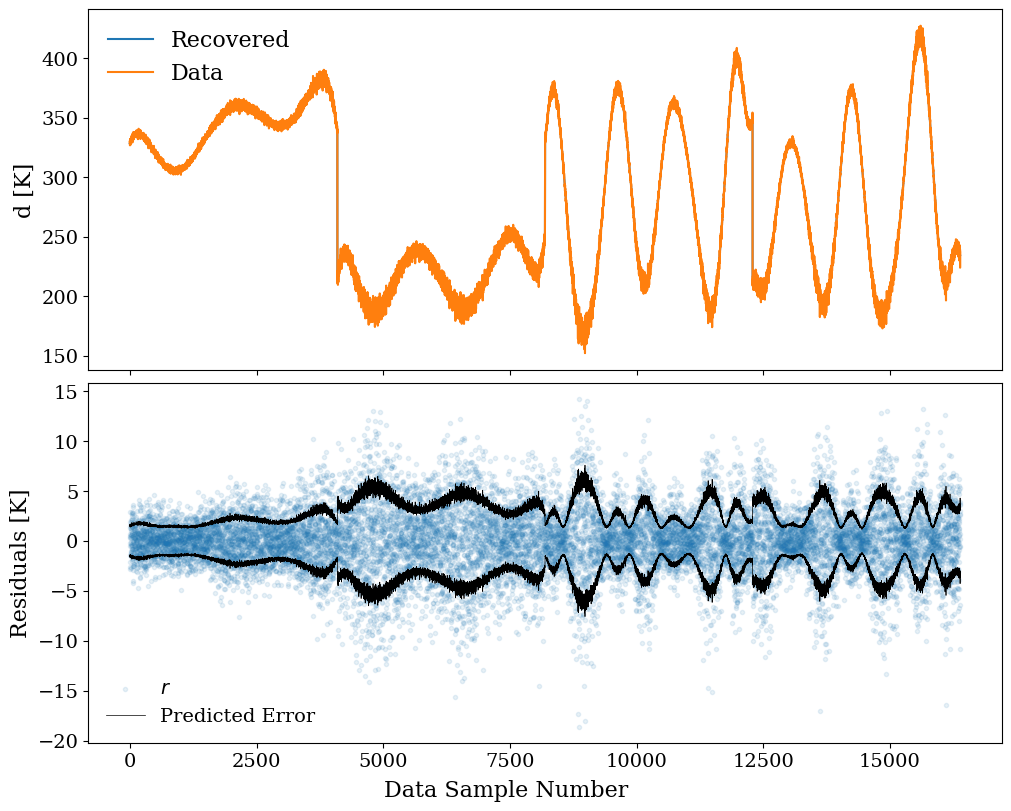

In [14]:
## Plot residuals from reconstructed data with recovered noise-wave params

# maybe plot resiudals with recovered data

recovered_d = H_matrix @ params


fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, layout='constrained')
ax1.plot(recovered_d, label='Recovered')
ax1.plot(d_flat, label='Data')
ax1.legend(frameon=False, fontsize=16)
ax1.set_ylabel('d [K]', fontsize=16)
ax1.tick_params('both', labelsize=14)
ax2.scatter(np.arange(len(d_flat)), d_flat - recovered_d, marker='.',alpha=0.1,
            label=r'$r$')
ax2.set_ylabel('Residuals [K]', fontsize=16)
ax2.plot(np.sqrt(ncov_waterfall.flatten()), 'k-', lw=0.5)
ax2.plot(-np.sqrt(ncov_waterfall.flatten()), 'k-', label='Predicted Error', lw=0.5)
ax2.tick_params('both', labelsize=14)
ax2.legend(fontsize=14, frameon=False)
fig.supxlabel('Data Sample Number', fontsize=16)
plt.gcf().set_size_inches((10., 8.))
plt.show()

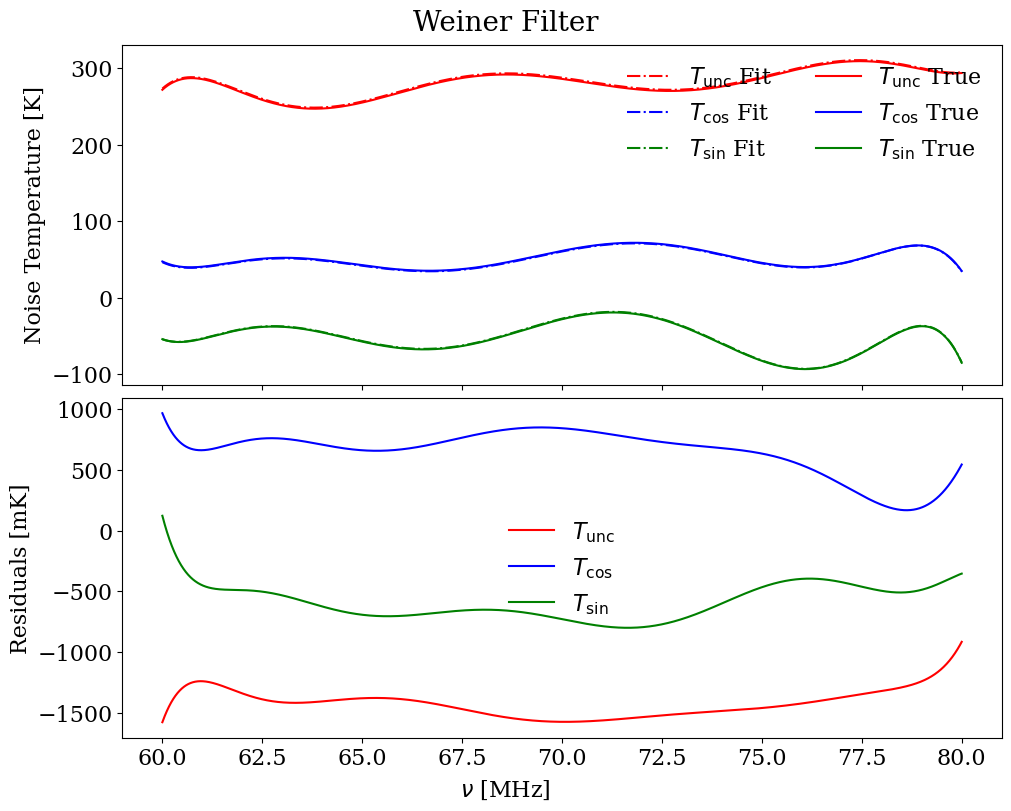

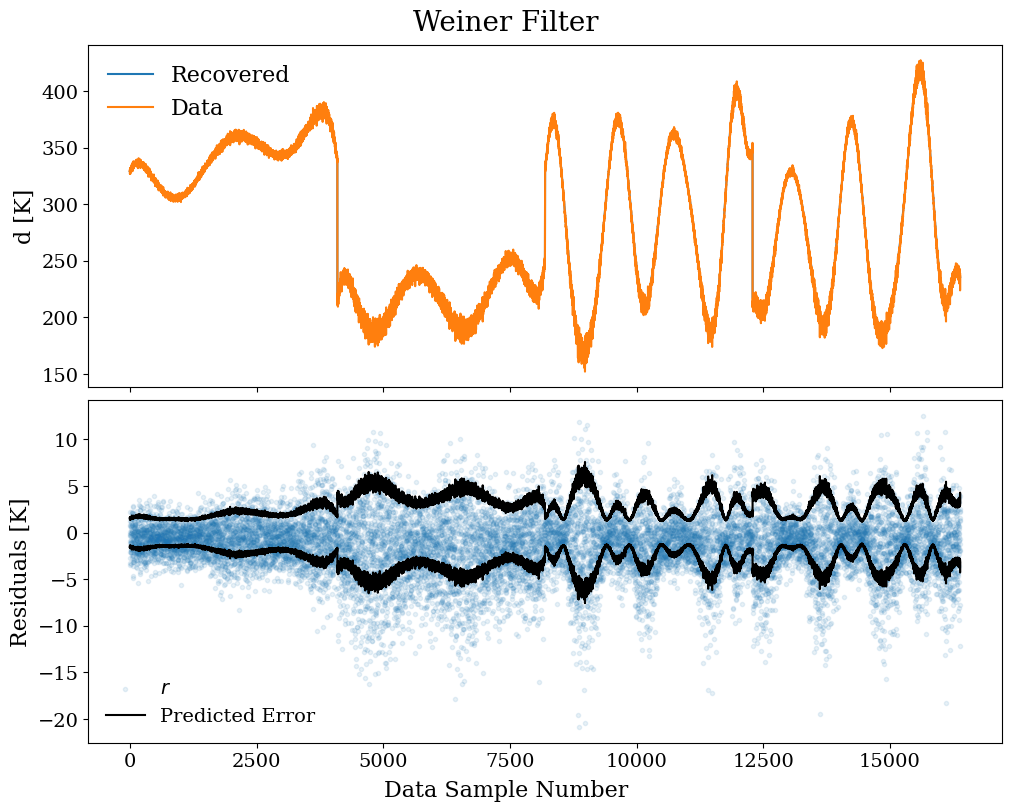

In [15]:

prior_params = params
signal_inv_covariance = (0.5 / np.abs(params))**2## = (0.05/ np.abs(params))**2

test_n_inv = np.ones_like(N_inv) / 1000

lhs = noise_wave_gcr.construct_gcr_lhs(H_matrix, N_inv, 0)
rhs = noise_wave_gcr.construct_gcr_rhs(H_matrix=H_matrix,
                                       N_inv_1d=N_inv,
                                       S_inv=signal_inv_covariance,
                                       d=d_flat,
                                       T_nw0=prior_params,
                                       omega_d=np.random.random(size=d_flat.shape),
                                       omega_t=np.zeros_like(params))
    
paramsw = cg(lhs, rhs, x0=prior_params)[0]

unc_funcw, cos_funcw, sin_funcw = return_spectrum_polynomial(paramsw,
                                                          unc_polyorder=unc_polyorder,
                                                          cos_polyorder=cos_polyorder,
                                                          sin_polyorder=sin_polyorder,
                                                          reference_freq=reference_frequency)


fig, (ax1, ax2) = plt.subplots(nrows=2,
                               sharex=True,
                               layout='constrained')

ax1.plot(freqs / 1e6, unc_funcw(freqs),'r-.', label=r'$T_{\rm unc}$ Fit')
ax1.plot(freqs / 1e6, cos_funcw(freqs),'b-.', label=r'$T_{\rm cos}$ Fit')
ax1.plot(freqs / 1e6, sin_funcw(freqs),'g-.', label=r'$T_{\rm sin}$ Fit')
ax1.plot(freqs / 1e6, T_unc, 'r-', label=r'$T_{\rm unc}$ True')
ax1.plot(freqs / 1e6, T_cos,'b-', label=r'$T_{\rm cos}$ True')
ax1.plot(freqs / 1e6, T_sin,'g-', label=r'$T_{\rm sin}$ True')

ax1.set_ylabel('Noise Temperature [K]', fontsize=16)
ax1.legend(fontsize=16, frameon=False, ncols=2)
ax1.tick_params('both', labelsize=16)

ax2.plot(freqs / 1e6, 1000*T_unc - 1000*unc_funcw(freqs) , 'r-', label=r'$T_{\rm unc}$')
ax2.plot(freqs / 1e6, 1000*T_cos - 1000*cos_funcw(freqs),'b-', label=r'$T_{\rm cos}$')
ax2.plot(freqs / 1e6, 1000*T_sin - 1000*sin_funcw(freqs),'g-', label=r'$T_{\rm sin}$')
ax2.set_ylabel('Residuals [mK]', fontsize=16)
ax2.tick_params('both', labelsize=16)
ax2.legend(frameon=False, fontsize=16)
fig.supxlabel(r'$\nu$ [MHz]', fontsize=16)
fig.suptitle('Weiner Filter', fontsize=20)
plt.gcf().set_size_inches((10., 8.))
plt.show()

## Plot residuals from reconstructed data with recovered noise-wave params

recovered_dw = H_matrix @ paramsw


fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, layout='constrained')
ax1.plot(recovered_dw, label='Recovered')
ax1.plot(d_flat, label='Data')
ax1.legend(frameon=False, fontsize=16)
ax1.set_ylabel('d [K]', fontsize=16)
ax1.tick_params('both', labelsize=14)
ax2.scatter(np.arange(len(d_flat)), d_flat - recovered_dw, marker='.',alpha=0.1,
            label=r'$r$')
ax2.set_ylabel('Residuals [K]', fontsize=16)
ax2.plot(np.sqrt(ncov_waterfall.flatten()), 'k-')
ax2.plot(-np.sqrt(ncov_waterfall.flatten()), 'k-', label='Predicted Error')
ax2.tick_params('both', labelsize=14)
ax2.legend(fontsize=14, frameon=False)
fig.supxlabel('Data Sample Number', fontsize=16)
fig.suptitle('Weiner Filter', fontsize=20)
plt.gcf().set_size_inches((10., 8.))
plt.show()

[-1.31047345e+08  9.45159600e+08 -2.57774717e+09  2.87477262e+09
  1.51050089e+08 -3.01025987e+09  1.04154654e+09  2.98472348e+09
 -3.68852848e+09  1.70430474e+09 -2.93973917e+08  1.27615872e+08
 -9.22310106e+08  2.50903257e+09 -2.77548127e+09 -1.74803154e+08
  2.90138487e+09 -9.62754488e+08 -2.87083310e+09  3.48986241e+09
 -1.59357164e+09  2.71858114e+08  2.02311724e+08 -1.45385653e+09
  3.93501401e+09 -4.33185229e+09 -2.75074841e+08  4.49535648e+09
 -1.48449186e+09 -4.41386873e+09  5.34441218e+09 -2.43113773e+09
  4.13187558e+08]
[-1.31047345e+08  9.45159600e+08 -2.57774717e+09  2.87477262e+09
  1.51050089e+08 -3.01025987e+09  1.04154654e+09  2.98472348e+09
 -3.68852848e+09  1.70430474e+09 -2.93973916e+08  1.27615872e+08
 -9.22310106e+08  2.50903257e+09 -2.77548127e+09 -1.74803154e+08
  2.90138487e+09 -9.62754488e+08 -2.87083310e+09  3.48986241e+09
 -1.59357164e+09  2.71858114e+08  2.02311724e+08 -1.45385653e+09
  3.93501401e+09 -4.33185229e+09 -2.75074841e+08  4.49535648e+09
 -1.484

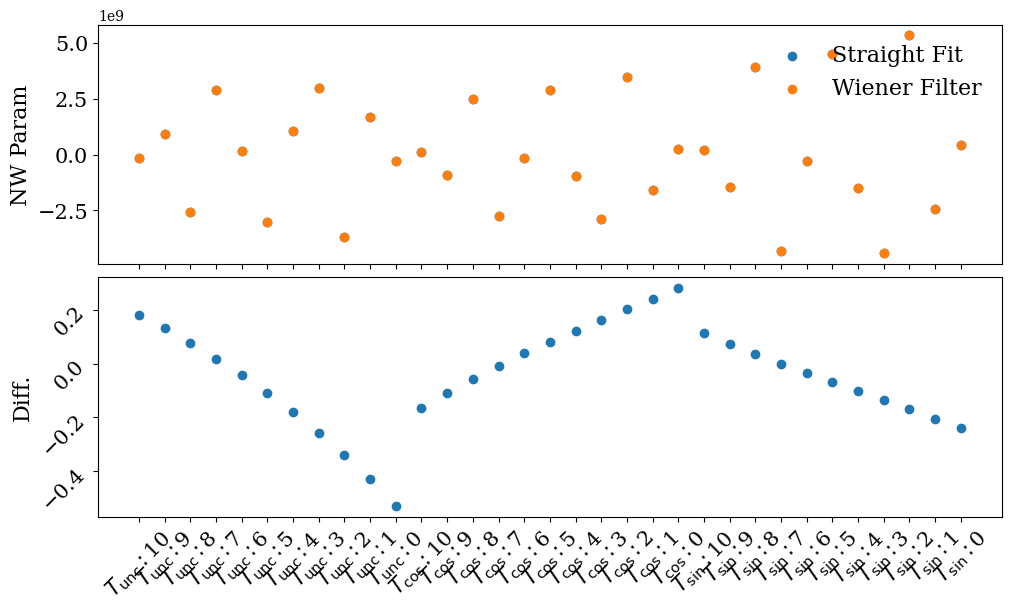

In [16]:
print(params)
print(paramsw)

x_labels = []

for i in range(unc_polyorder+1):
    x_labels.append(r'$T_{\rm unc}:$'+f'{unc_polyorder - i }')
for i in range(cos_polyorder+1):
    x_labels.append(r'$T_{\rm cos}:$'+f'{cos_polyorder - i}')
for i in range(sin_polyorder+1):
    x_labels.append(r'$T_{\rm sin}:$'+f'{sin_polyorder -i}')




fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, layout='constrained')
ax1.scatter(x_labels, params, label='Straight Fit')
ax1.scatter(x_labels, paramsw, label='Wiener Filter')
ax2.scatter(x_labels, params - paramsw)
ax1.legend(frameon=False, fontsize=16)
ax1.set_ylabel('NW Param', fontsize=16)
ax2.set_ylabel('Diff.', fontsize=16)
for ax in [ax1, ax2]:
    ax.tick_params('both', labelsize=15)
ax2.tick_params(rotation=45)
plt.gcf().set_size_inches((10., 6.))
plt.show()


In [17]:
params_list = []
for _ in range(3000):
    omega_d = np.random.normal(loc=0, scale=1, size=d_flat.shape)
    omega_t = np.random.normal(loc=0, scale=1, size=params.shape)
    lhs = noise_wave_gcr.construct_gcr_lhs(H_matrix, N_inv, signal_inv_covariance)
    rhs = noise_wave_gcr.construct_gcr_rhs(H_matrix, N_inv, signal_inv_covariance, d_flat,
                                           paramsw, omega_t, omega_d)
    params_list.append(cg(lhs, rhs, x0=paramsw)[0])
params_list = np.array(params_list)

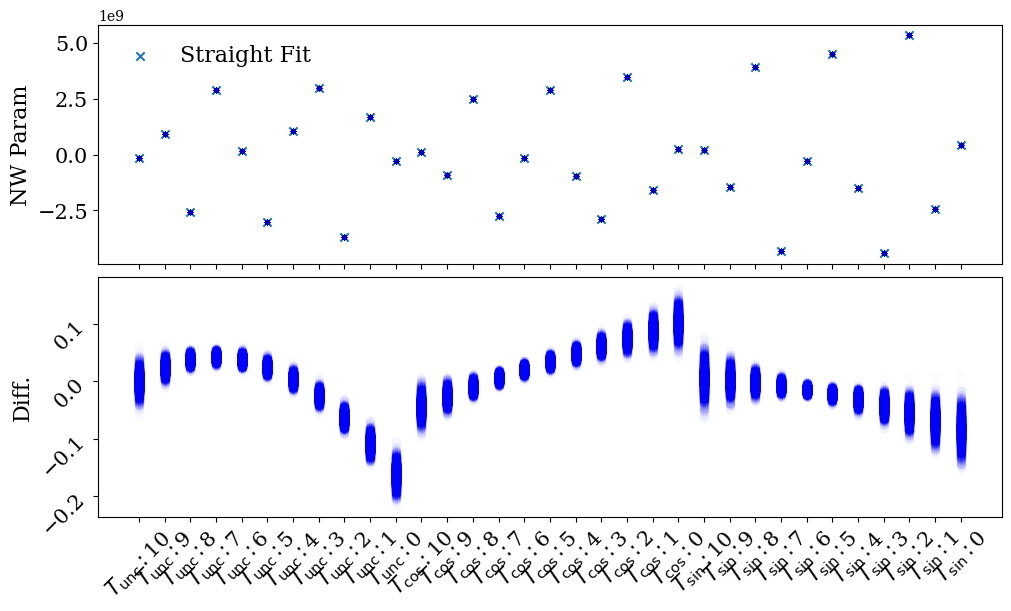

In [18]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, layout='constrained')
ax1.scatter(x_labels, params, marker='x', label='Straight Fit')
for p in params_list:
    ax1.scatter(x_labels, p, alpha=0.01, c='b', marker='.')
    ax2.scatter(x_labels, params - p, c='b', alpha=0.01)
ax1.legend(frameon=False, fontsize=16)
ax1.set_ylabel('NW Param', fontsize=16)
ax2.set_ylabel('Diff.', fontsize=16)
for ax in [ax1, ax2]:
    ax.tick_params('both', labelsize=15)
ax2.tick_params(rotation=45)
plt.gcf().set_size_inches((10., 6.))
plt.show()

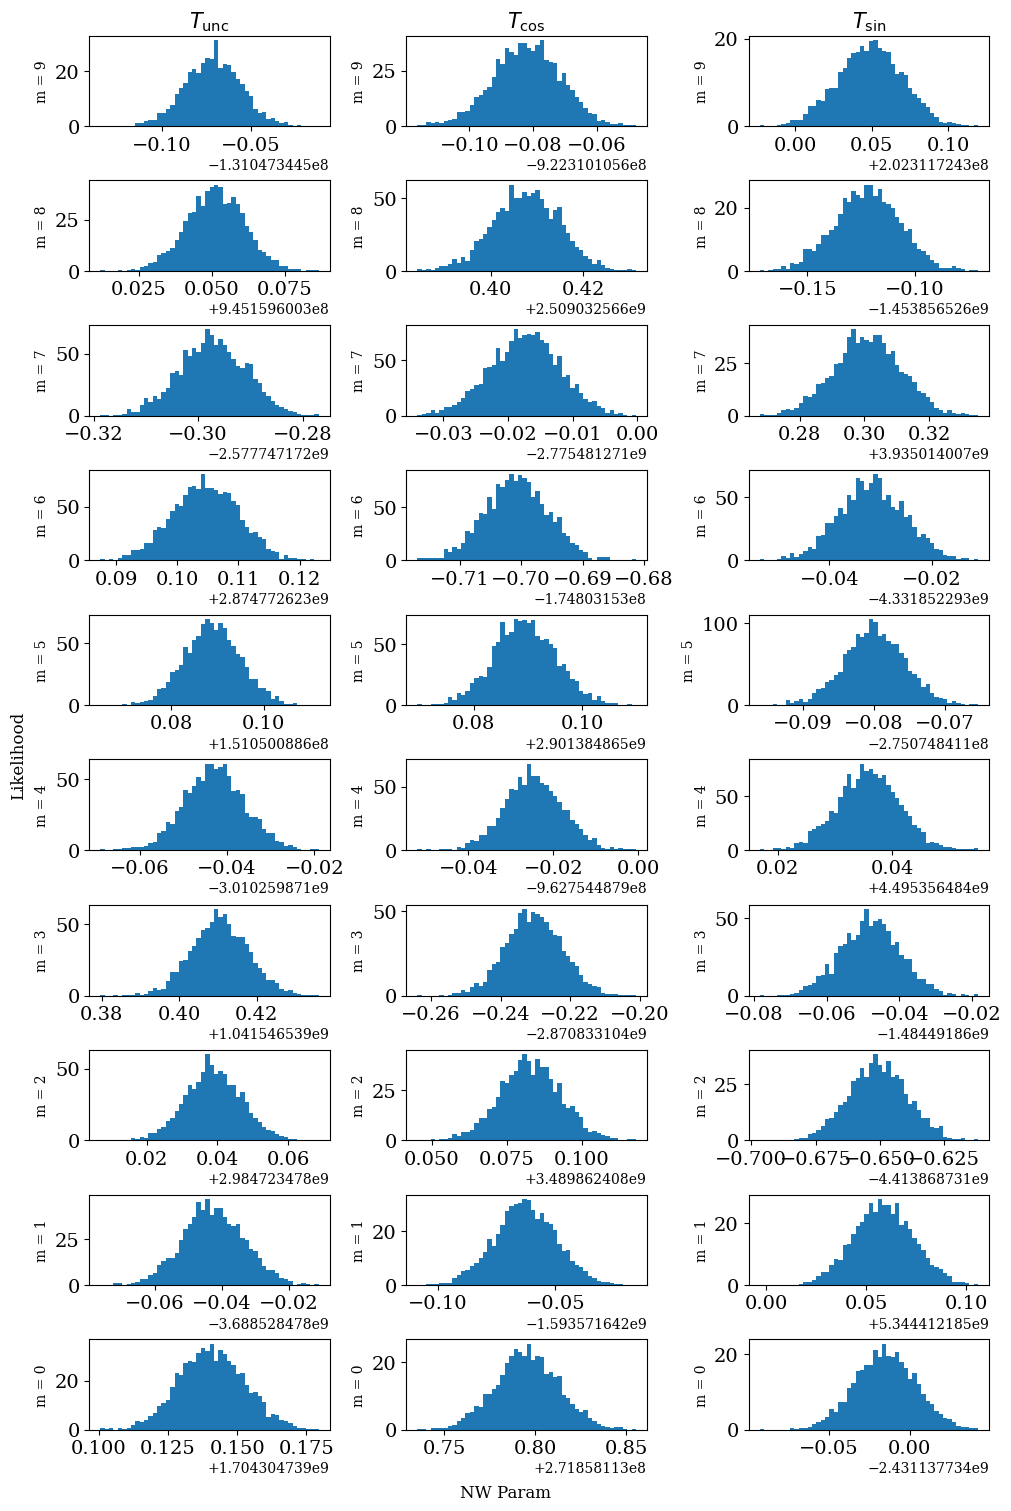

In [19]:

fig, axes = plt.subplots(ncols=3,layout='constrained',
                         nrows=max([unc_polyorder, sin_polyorder, cos_polyorder]))

for i in range(unc_polyorder):
    axes[i, 0].hist(params_list.T[i], bins=50, density=True)
    axes[i, 0].tick_params('both', labelsize=14)
    axes[i,0].set_ylabel(r'm = '+f'{unc_polyorder-i-1}')
for i in range(cos_polyorder):
    axes[i, 1].hist(params_list.T[unc_polyorder+2+i], bins=50, density=True)
    axes[i, 1].tick_params('both', labelsize=14)
    axes[i,1].set_ylabel(r'm = '+f'{cos_polyorder-i-1}')

for i in range(sin_polyorder):
    axes[i, 2].hist(params_list.T[unc_polyorder+cos_polyorder+2+i], bins=50, density=True)
    axes[i, 2].tick_params('both', labelsize=14)
    axes[i,2].set_ylabel(r'm = '+f'{sin_polyorder-i-1}')

axes[0,0].set_title(r'$T_{\rm unc}$', fontsize=15)
axes[0,1].set_title(r'$T_{\rm cos}$', fontsize=15)
axes[0,2].set_title(r'$T_{\rm sin}$', fontsize=15)



fig.supxlabel('NW Param')
fig.supylabel('Likelihood')
plt.gcf().set_size_inches((10., 15.))
plt.show()

In [20]:
T_unc_rec = []
T_cos_rec = []
T_sin_rec = []

for p in params_list:
    unc_funcw, cos_funcw, sin_funcw = return_spectrum_polynomial(p,
                                                          unc_polyorder=unc_polyorder,
                                                          cos_polyorder=cos_polyorder,
                                                          sin_polyorder=sin_polyorder,
                                                          reference_freq=reference_frequency)
    T_unc_rec.append(unc_funcw(freqs))
    T_cos_rec.append(cos_funcw(freqs))
    T_sin_rec.append(sin_funcw(freqs))
    pass
T_unc_rec = np.array(T_unc_rec)
T_cos_rec = np.array(T_cos_rec)
T_sin_rec = np.array(T_sin_rec)

(4096,)


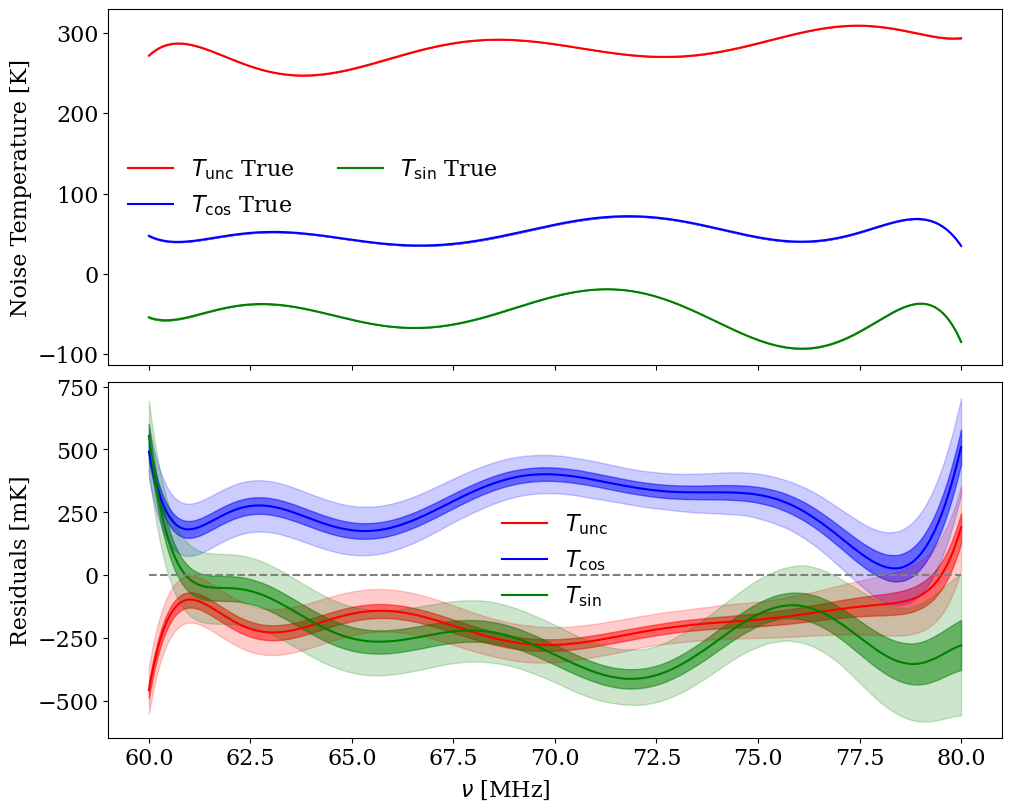

In [21]:
fig, (ax1, ax2) = plt.subplots(nrows=2,
                               sharex=True,
                               layout='constrained')


ax1.plot(freqs / 1e6, T_unc, 'r-', label=r'$T_{\rm unc}$ True')
ax1.plot(freqs / 1e6, T_cos,'b-', label=r'$T_{\rm cos}$ True')
ax1.plot(freqs / 1e6, T_sin,'g-', label=r'$T_{\rm sin}$ True')

# Plot 68 % quantile

print(freqs.shape)

ax1.fill_between(x=freqs / 1e6,
                y1= np.quantile(T_unc_rec, (0.5 - (0.68/2)), axis=0),
                y2= np.quantile(T_unc_rec, (0.5 + (0.68/2)), axis=0), color='r', alpha=0.5)
ax1.fill_between(x=freqs / 1e6,
                y1= np.quantile(T_cos_rec, (0.5 - (0.68/2)), axis=0),
                y2= np.quantile(T_cos_rec, (0.5 + (0.68/2)), axis=0), color='b', alpha=0.5)
ax1.fill_between(x=freqs / 1e6,
                y1= np.quantile(T_sin_rec, (0.5 - (0.68/2)), axis=0),
                y2= np.quantile(T_sin_rec, (0.5 + (0.68/2)), axis=0), color='g', alpha=0.5)

ax1.fill_between(x=freqs / 1e6,
                y1= np.quantile(T_unc_rec, (0.5 - (0.997/2)), axis=0),
                y2= np.quantile(T_unc_rec, (0.5 + (0.997/2)), axis=0), color='r', alpha=0.1)
ax1.fill_between(x=freqs / 1e6,
                y1= np.quantile(T_cos_rec, (0.5 - (0.997/2)), axis=0),
                y2= np.quantile(T_cos_rec, (0.5 + (0.997/2)), axis=0), color='b', alpha=0.1)
ax1.fill_between(x=freqs / 1e6,
                y1= np.quantile(T_sin_rec, (0.5 - (0.997/2)), axis=0),
                y2= np.quantile(T_sin_rec, (0.5 + (0.997/2)), axis=0), color='g', alpha=0.1)

ax1.set_ylabel('Noise Temperature [K]', fontsize=16)
ax1.legend(fontsize=16, frameon=False, ncols=2)
ax1.tick_params('both', labelsize=16)

ax2.plot(freqs / 1e6, 1000*T_unc - 1000*np.median(T_unc_rec, axis=0) , 'r-', label=r'$T_{\rm unc}$')
ax2.plot(freqs / 1e6, 1000*T_cos - 1000*np.median(T_cos_rec, axis=0) ,'b-', label=r'$T_{\rm cos}$')
ax2.plot(freqs / 1e6, 1000*T_sin - 1000*np.median(T_sin_rec, axis=0),'g-', label=r'$T_{\rm sin}$')

ax2.fill_between(x=freqs / 1e6,
                y1= 1000*T_unc - 1000*np.quantile(T_unc_rec, (0.5 - (0.68/2)), axis=0),
                y2= 1000*T_unc - 1000*np.quantile(T_unc_rec, (0.5 + (0.68/2)), axis=0), color='r', alpha=0.5)
ax2.fill_between(x=freqs / 1e6,
                y1= 1000*T_cos - 1000*np.quantile(T_cos_rec, (0.5 - (0.68/2)), axis=0),
                y2= 1000*T_cos - 1000*np.quantile(T_cos_rec, (0.5 + (0.68/2)), axis=0), color='b', alpha=0.5)
ax2.fill_between(x=freqs / 1e6,
                y1= 1000*T_sin - 1000*np.quantile(T_sin_rec, (0.5 - (0.68/2)), axis=0),
                y2= 1000*T_sin - 1000*np.quantile(T_sin_rec, (0.5 + (0.68/2)), axis=0), color='g', alpha=0.5)

ax2.fill_between(x=freqs / 1e6,
                y1= 1000*T_unc - 1000*np.quantile(T_unc_rec, (0.5 - (0.997/2)), axis=0),
                y2= 1000*T_unc - 1000*np.quantile(T_unc_rec, (0.5 + (0.997/2)), axis=0), color='r', alpha=0.2)
ax2.fill_between(x=freqs / 1e6,
                y1= 1000*T_cos - 1000*np.quantile(T_cos_rec, (0.5 - (0.997/2)), axis=0),
                y2= 1000*T_cos - 1000*np.quantile(T_cos_rec, (0.5 + (0.997/2)), axis=0), color='b', alpha=0.2)
ax2.fill_between(x=freqs / 1e6,
                y1= 1000*T_sin - 1000*np.quantile(T_sin_rec, (0.5 - (0.997/2)), axis=0),
                y2= 1000*T_sin - 1000*np.quantile(T_sin_rec, (0.5 + (0.997/2)), axis=0), color='g', alpha=0.2)

ax2.hlines(0, min(freqs / 1e6) ,max(freqs / 1e6), linestyles='dashed', colors='grey')

ax2.set_ylabel('Residuals [mK]', fontsize=16)
ax2.tick_params('both', labelsize=16)
ax2.legend(frameon=False, fontsize=16)
fig.supxlabel(r'$\nu$ [MHz]', fontsize=16)
#fig.suptitle('Weiner Filter', fontsize=20)
plt.gcf().set_size_inches((10., 8.))
plt.show()

In [22]:
from utils.utils import chebyshev_model_2d



In [23]:
# def build_basis(x, y, n_x_coeffs, n_y_coeffs):
#     Vx = np.vander(x, n_x_coeffs)
#     Vy = np.vander(y, n_y_coeffs)

#     B = (Vx[:,None,:,None] * Vy[None,:,None,:]).reshape(x.size * y.size,
#                                                         n_x_coeffs * n_y_coeffs)

#     return B


# freqs = np.linspace(60, 80, 1024)
# times = np.linspace(0, 3600, 10)


# def construct_basis(freqs, times, n_freq_coeffs, n_time_coeffs):
#     n_freqs, n_times = len(freqs), len(times)
#     ff, tt = np.meshgrid(freqs, times)
#     flat_freqs, flat_times = ff.flatten(), tt.flatten()

#     flat_freq_vander = np.vander(flat_freqs, n_freq_coeffs)
#     flat_times_vander = np.vander(flat_times, n_time_coeffs)

#     basis = np.empty(shape=(n_freqs*n_times,
#                                n_freq_coeffs*n_time_coeffs))
    
#     for i in range(int(n_freqs*n_times)):
#         fp, tp = np.meshgrid(flat_freq_vander[i],
#                              flat_times_vander[i])
#         basis[i] = (fp*tp).flatten()
    
#     return basis


# basis  = construct_basis(freqs=freqs,
#                 times=times,
#                 n_freq_coeffs=3,
#                 n_time_coeffs=2)

# def reconstruct_surface(coeffs, x, y):
#     n_x_coeffs, n_y_coeffs = coeffs.shape

#     Vx = np.vander(x, N=n_x_coeffs)
#     Vy = np.vander(y, N=n_y_coeffs)

#     return Vx @ coeffs @ Vy.T



### Test case to make easier implementation

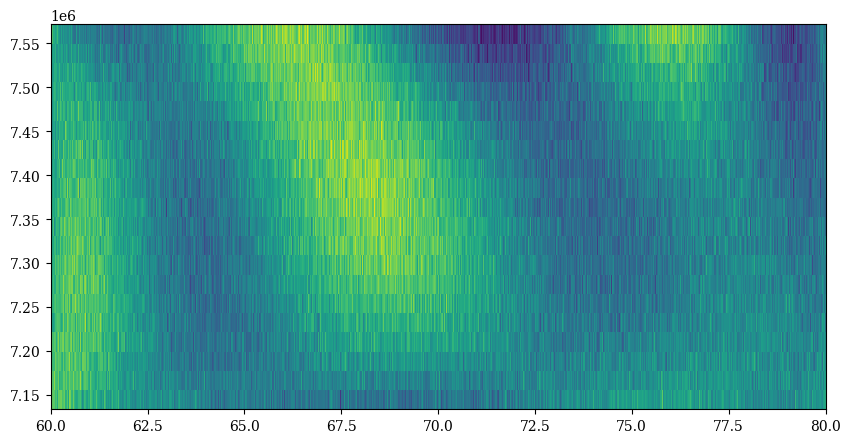

NameError: name 'construct_basis' is not defined

In [24]:
freqs = np.linspace(60, 80, num=4096)

times = np.linspace(7144561, 7144561+416315, num=20)

test_surface = 300 + chebyshev_model_2d(freqs=freqs,
                                        times=times,
                                        n_freq_coeffs=8,
                                        n_time_coeffs=3,
                                        amp=20)
test_surface += np.random.normal(size=test_surface.shape, scale=5)
plt.pcolormesh(freqs, times, test_surface)
plt.show()


def fit_surface(freqs,
                times,
                n_freq_coeffs,
                n_time_coeffs,
                data):
    bandwidth = freqs[-1] - freqs[0]
    n_freqs = len(freqs)

    time_span = times[-1] - times[0]

    x_span = (freqs - freqs[0]) / bandwidth
    y_span = (times - times[0]) / time_span

    basis = construct_basis(x_span,
                            y_span,
                            n_freq_coeffs,
                            n_time_coeffs)
    
    coeffs, *_ = np.linalg.lstsq(basis, data.flatten())
    coeffs = coeffs.reshape(n_freq_coeffs, n_time_coeffs)

    def freq_to_xspan(f):
        return (f - freqs[0]) / bandwidth

    def time_to_yspan(t):
        return (t - times[0]) / time_span

    return coeffs, freq_to_xspan, time_to_yspan


def reconstruct_surface(freqs,
                        times,
                        coeffs,
                        freq_to_xspan,
                        time_to_yspan):
    x_span = freq_to_xspan(freqs)
    y_span = time_to_yspan(times)
    print(coeffs)

    n_freq_coeffs, n_time_coeffs = coeffs.shape

    basis = construct_basis(x_span,
                            y_span,
                            n_freq_coeffs,
                            n_time_coeffs)
    
    n_freqs, n_times = len(freqs), len(times)

    data_reconstruct = basis @ coeffs.flatten()

    print(data_reconstruct)

    data_reconstruct = np.reshape(data_reconstruct, shape=(n_times, n_freqs))
    return data_reconstruct


coeffs, freq_to_xspan, time_to_yspan = fit_surface(freqs=freqs,
                     times=times,
                     n_freq_coeffs=8,
                     n_time_coeffs=6,
                     data=test_surface)

new_freqs = np.linspace(60, 80, 1024)
new_times = np.linspace(7144561, 7144561+416315, num=100)


reconstructed_surface = reconstruct_surface(new_freqs,
                                            new_times,
                                            coeffs=coeffs,
                                            freq_to_xspan=freq_to_xspan,
                                            time_to_yspan=time_to_yspan)


plt.pcolormesh(reconstructed_surface)
plt.show()

In [ ]:
matrix = np.ones(shape=(5,10))

print(matrix[0])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:


data_waterfall

gamma_src_list[0]
gamma_src_list_labels


gamma_src_dict = {}

for src_label, g_src in zip(gamma_src_list_labels,
                            gamma_src_list):
    gamma_src_dict[src_label] = g_src





times_array = np.linspace(0, 3600, len(gamma_src_list))
switch_states_array = np.array(gamma_src_list_labels)
freq_array = freqs
print(switch_states_array)

['Open' 'Short' 'Open - 20 m' 'Shorted - 20 m']


In [ ]:

H_matrix_new = transfer_matrix_construction.construct_transfer_matrix(freq_array=freq_array,
                                                                  time_array=times_array,
                                                                  switch_states_array=switch_states_array,
                                                                  unc_poly_orders=(10,1),
                                                                  cos_poly_orders=(10,1),
                                                                  sin_poly_orders=(10,1),
                                                                  switch_state_src_gamma_dict=gamma_src_dict,
                                                                  gamma_rec=gamma_rec)



H_matrix = noise_wave_gcr.construct_H_matrix(freq_array,
                                             gamma_src_list=gamma_src_list,
                                             gamma_rec=gamma_rec,
                                             unc_polyorder=9,
                                             cos_polyorder=9,
                                             sin_polyorder=9,
                                             reference_frequency=reference_frequency)

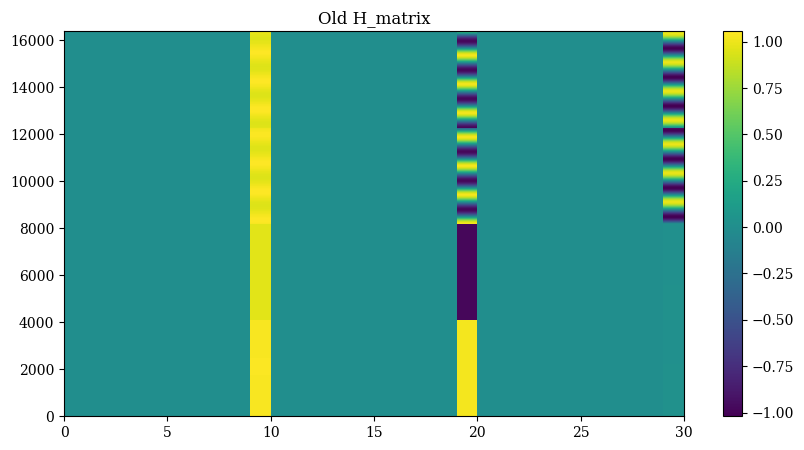

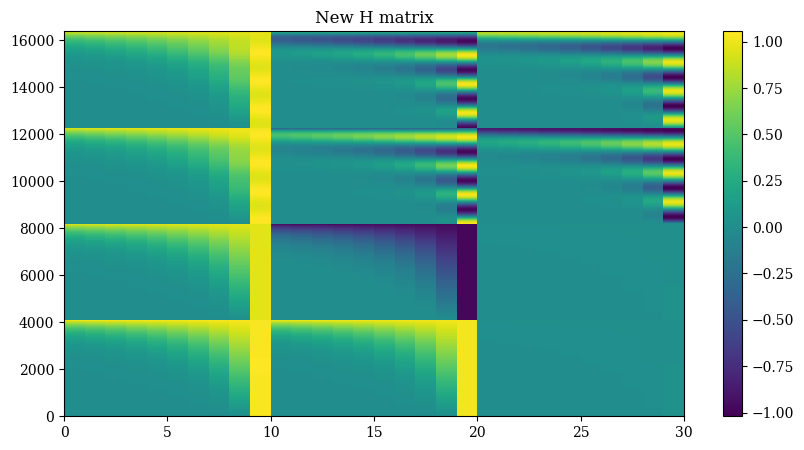

In [ ]:
plt.pcolormesh(H_matrix)
plt.colorbar()
plt.title('Old H_matrix')
plt.show()
plt.pcolormesh(H_matrix_new)
plt.colorbar()
plt.title("New H matrix")
plt.show()

In [ ]:
coeffs_old, *_ = np.linalg.lstsq(H_matrix, d_flat)
coeffs_new, *_ = np.linalg.lstsq(H_matrix_new, d_flat)

In [ ]:
print(coeffs)
print(coeffs_new)

[[-1.40358239e+05  4.92523476e+05 -6.92946724e+05  4.97683144e+05
  -1.91309384e+05  3.74570805e+04]
 [-3.26309343e+03  1.17774040e+02  3.68560507e+05 -1.27524412e+06
   1.76407042e+06 -1.24217211e+06]
 [ 4.67032739e+05 -8.93380573e+04  7.63565177e+03 -2.77459280e+02
  -3.31933727e+05  1.13266490e+06]
 [-1.54052310e+06  1.06290483e+06 -3.90157972e+05  7.26159375e+04
  -6.05447822e+03  2.20754696e+02]
 [-1.28522487e+05  5.25677635e+05 -8.65418773e+05  7.21373031e+05
  -3.11043718e+05  6.16650582e+04]
 [-3.50339622e+03 -1.14957993e+02  3.25185216e+05 -1.17741725e+06
   1.71431936e+06 -1.27349054e+06]
 [ 4.99241409e+05 -9.37564969e+04  5.85548773e+03  5.07982742e+01
  -9.74054256e+04  3.37467389e+05]
 [-4.62094986e+05  3.17376608e+05 -1.13619909e+05  1.93660624e+04
  -1.08135327e+03  2.90815720e+02]]
[ 6.02000825e+03 -2.83932193e+04 -1.40066323e+05  6.14794624e+05
 -8.83257283e+05  6.20324954e+05 -2.28631327e+05  4.23214772e+04
 -3.30879724e+03  3.80991386e+02  9.42051027e+03 -4.33419295e

In [ ]:
from gcr.basis_construction import array_normalisation, reconstruct_surface


In [ ]:
_, freq_norm_func = array_normalisation(freq_array)
_, time_norm_func = array_normalisation(times_array)

unc_surface = reconstruct_surface(x=freq_array,
                                  y=times_array,
                                  flat_coeffs=coeffs_new[:10],
                                  n_y_coeffs=1,
                                  n_x_coeffs=10,
                                  x_array_norm_func=freq_norm_func,
                                  y_array_norm_func=time_norm_func)




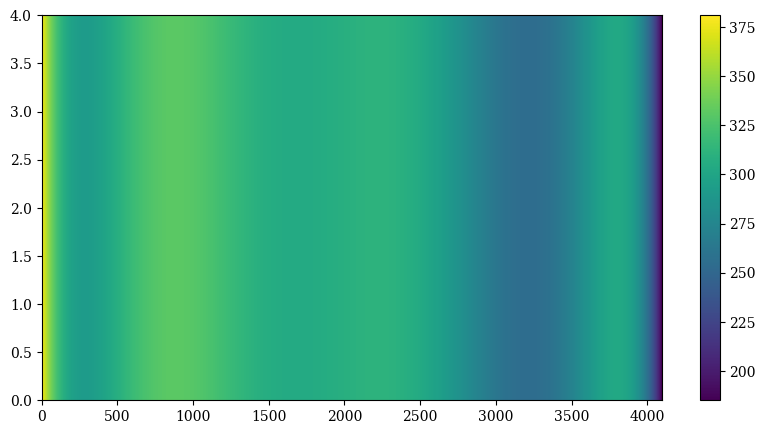

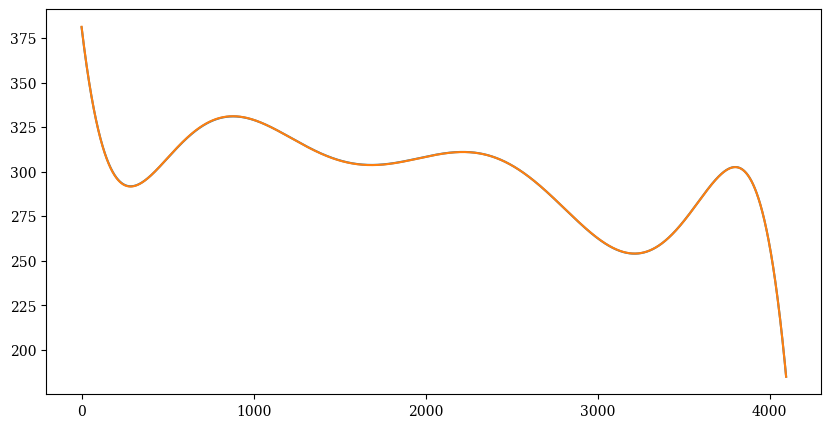

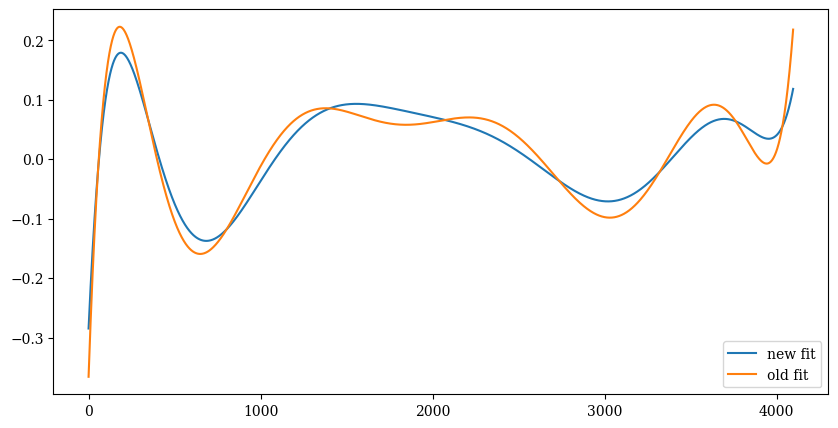

In [ ]:
plt.pcolormesh(unc_surface)
plt.colorbar()
plt.show()

plt.plot(np.mean(unc_surface, axis=0))
plt.plot(T_unc)
plt.show()

plt.plot(np.mean(unc_surface, axis=0) - T_unc, label='new fit')
plt.plot(old_fit_t_unc - T_unc, label='old fit')
plt.legend()
plt.show()